In [1]:
import sys
import os
from pathlib import Path

notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent
print(ROOT)
RAFT_PATH = ROOT / "external" / "RAFT-Stereo"
os.chdir(ROOT)
if str(RAFT_PATH) not in sys.path:
    sys.path.append(str(ROOT))

/srv/homes/onbo10/thesis_main


In [2]:
from utilities.visualizer_triangulation import TriangulationVisualizer
from src.Geometry.triangulation.triangulator import Triangulator
import cv2
from src.Geometry.triangulation.triangulation_utils import *
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd
from src.Stereo_matching.stereo_matching_utils import *
from src.Stereo_matching.inference.RAFT_Stereo_inferencer import RAFTSTEREOInferencer
from src.Stereo_matching.inference.SGBM_matcher_inferencer import SGBMInferencer
from src.Stereo_matching.evaluation.compare_masks_disparities import disparity_vs_segmentation
from src.Segmentation.data_postprocessing.masks_postprocessing import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# Select examples selection and display variables
num_examples= 10
seed=10
fig_name= 'disparity_examples_2.png'
idx= 5


### Raft Stereo results

* #### Examples and plots

In [4]:
data_dir='data/SurgPose/SurgPose_for_HRNet/Extracted_right_test/extracted_frames'
results_dir= "results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo"
save_path= results_dir +  '/plots/'+ fig_name

In [5]:
selected_files= select_random_files(data_dir, num_examples, seed, file_path_structure="**/*.jpg")
left_img_root = 'data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames'
zip_root= 'data/SurgPose/SurgPose_for_HRNet'

In [6]:
cfg_path='configs/RAFT_STEREO/raft_stereo_surgpose_test_set.yaml'

In [7]:
with open(cfg_path, 'r') as f:
        config_data = yaml.safe_load(f)
raft_inferencer = RAFTSTEREOInferencer(config_data['model'], device='cuda')
img_shape= (config_data['h'],config_data['w'])

In [8]:
raft_disparities= compute_disparities(raft_inferencer, right_img_paths=selected_files, left_img_root=left_img_root, zip_root=zip_root, img_shape=img_shape)

/srv/homes/onbo10/.conda/envs/raftstereo/lib/python3.7/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1646755953518/work/aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


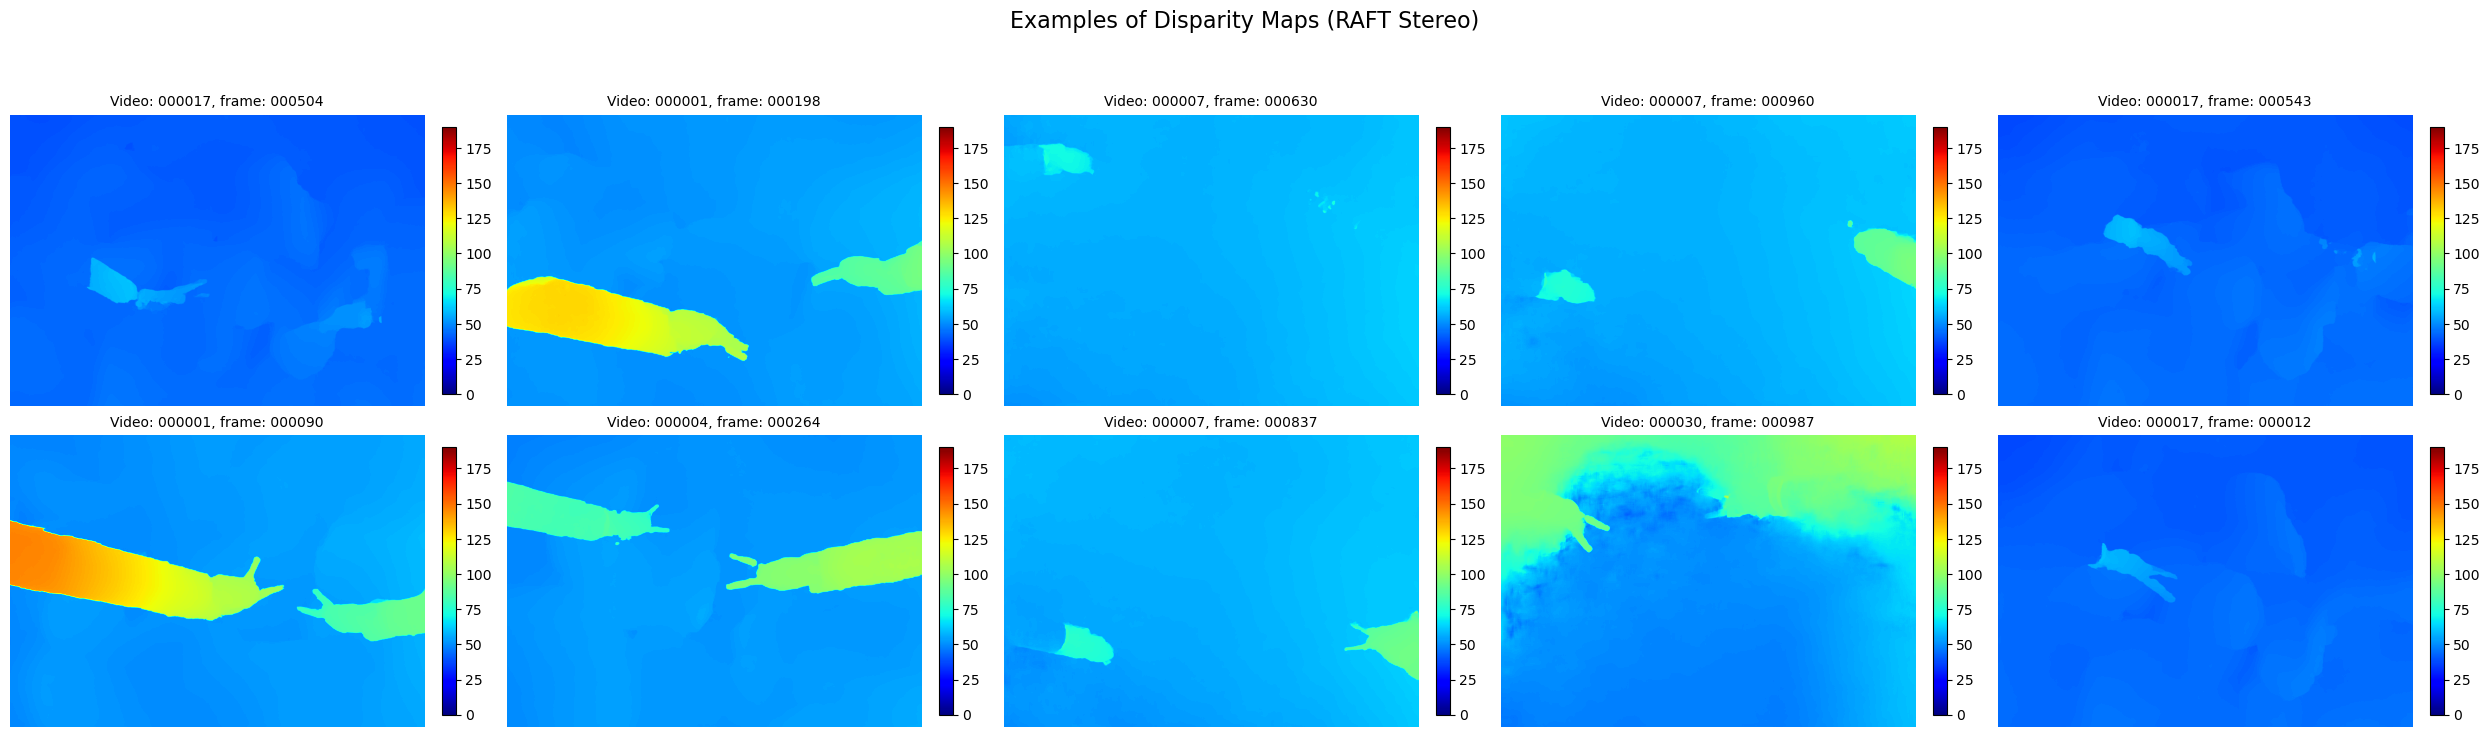

In [9]:
plot_selected_files(selected_files, raft_disparities, title= 'Examples of Disparity Maps (RAFT Stereo)',save_path=save_path, save= True)

In [10]:
selected_example_path= selected_files[idx]

In [11]:
left_mask_path, right_mask_path, zip_calib_path, left_img_path, right_img_path, frame_id=get_file_paths_from_compressed_file_path(selected_example_path, vid_id_position=0)

In [12]:
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path);

In [13]:
# load data
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [14]:
# rectify
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


In [15]:
# get left disparity 
disp_l =  raft_disparities[idx]


In [16]:
# 3D reconstruction
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(disp_l, q, rect_l, rect_mask_l)

In [17]:
# Plot 3D reconstruction
visualizer = TriangulationVisualizer()
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id+', RAFT Stereo original')

#### Identifying a Problem with the segmentation masks

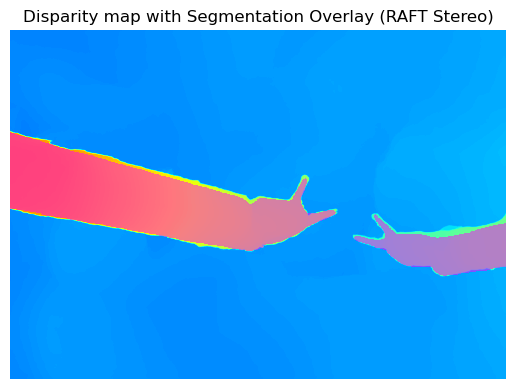

In [18]:

plt.imshow(disp_l, cmap='jet', vmin=0, vmax=190)
masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
plt.title('Disparity map with Segmentation Overlay (RAFT Stereo)')
plt.axis('off') 
plt.show()

In [19]:
#Erode segmentation mask
eroded_mask= erode_mask(rect_mask_l, iterations=3)

In [20]:
points_3d_cloud_eroded, colors, disparity = triangulator.project_disparity_to_3d(disp_l, q, rect_l, eroded_mask)

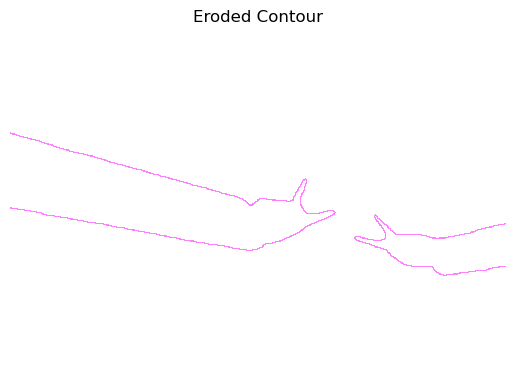

In [21]:

masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
masked_data_eroded = np.ma.masked_where(eroded_mask == 0, eroded_mask)
plt.imshow(masked_data_eroded, cmap='binary', alpha=1)
plt.title('Eroded Contour')
plt.axis('off') 
plt.show()

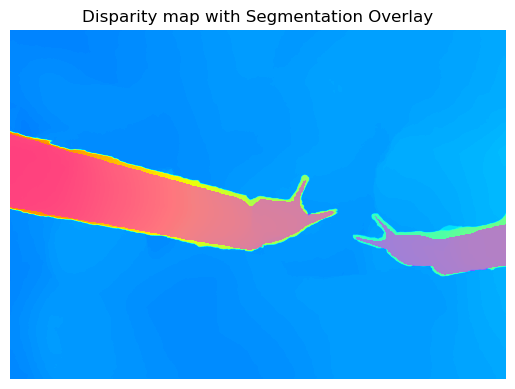

In [22]:
plt.imshow(disp_l, cmap='jet', vmin=0, vmax=190)
masked_data = np.ma.masked_where(eroded_mask == 0, eroded_mask)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
plt.title('Disparity map with Segmentation Overlay')
plt.axis('off') 
plt.show()

In [25]:
# Plot 3D reconstruction

visualizer = TriangulationVisualizer()

In [26]:

visualizer.plot_3d_plotly(points_3d=points_3d_cloud_eroded, colors=colors, frame_name=frame_id+', RAFT Stereo with eroded segmentation mask')

* ####  Evaluation stats

In [25]:
lrc_stats='results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo/lrc_stats_20260422_143449.csv'
df= pd.read_csv(lrc_stats)

In [26]:
df.head(10)

,video_id,frame,lrc_mean,lrc_std,lrc_max,lrc_min,consistency_rate,ssim_score,lrc_median
0,4,vid_000004_left_frame_000000,0.9906,4.8800,54.0064,0.0,91.92,0.6343,0.2142
1,4,vid_000004_left_frame_000003,1.1787,5.0705,56.4388,0.0,89.11,0.6008,0.2142
2,4,vid_000004_left_frame_000006,1.0677,5.4643,63.9004,0.0,92.49,0.6039,0.2372
3,4,vid_000004_left_frame_000009,1.0773,5.4838,63.4718,0.0,91.88,0.6029,0.2227
4,4,vid_000004_left_frame_000012,1.2045,5.7852,65.0734,0.0,89.74,0.5840,0.1908
5,4,vid_000004_left_frame_000015,1.1025,5.6855,67.4016,0.0,93.79,0.5994,0.1765
6,4,vid_000004_left_frame_000018,1.2036,6.0078,71.8710,0.0,92.35,0.6019,0.1879
7,4,vid_000004_left_frame_000021,1.0795,5.8420,69.1739,0.0,94.74,0.6017,0.1796
8,4,vid_000004_left_frame_000024,1.1177,5.7841,69.6130,0.0,94.17,0.5824,0.2234
9,4,vid_000004_left_frame_000027,1.2334,6.1028,66.2542,0.0,91.64,0.5988,0.2298


In [27]:
# display mean results
df.mean(numeric_only=True).drop('video_id')

lrc_mean             2.567003
lrc_std              6.023596
lrc_max             52.824355
lrc_min              0.000000
consistency_rate    75.343847
ssim_score           0.533273
lrc_median           0.855114
dtype: float64

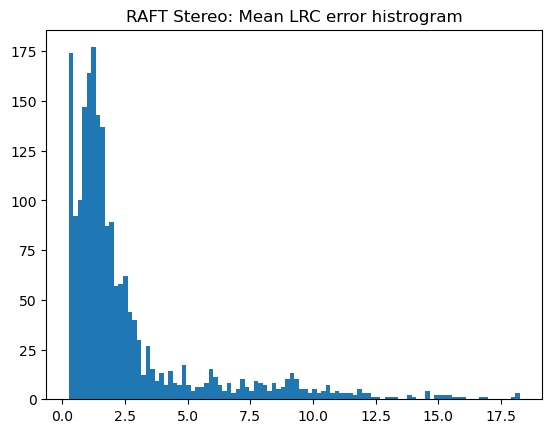

In [28]:
plt.hist(df['lrc_mean'], bins=100)
plt.title('RAFT Stereo: Mean LRC error histrogram')
plt.show()

#### Segmentation Mask quality exaluation

In [29]:
mask_csv_path='results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo/raftstereo_disparity_segmentation_masks_eval_postprocessing_both_masks.csv'
mask_df=pd.read_csv(mask_csv_path)

In [30]:
mask_df.mean(numeric_only=True)

Disparity threshold     55.757247
Hausdorff distance     300.844938
Dice score               0.637786
dtype: float64

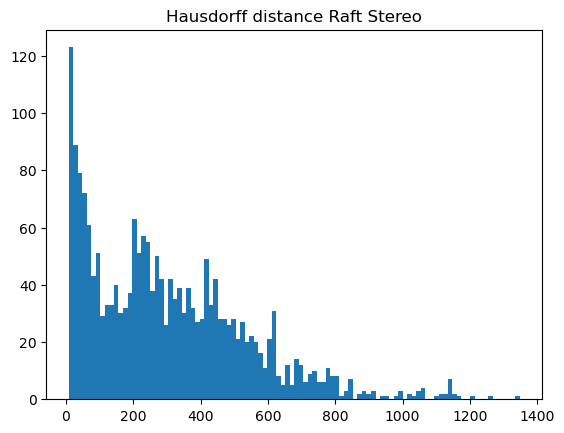

In [31]:
plt.hist(mask_df['Hausdorff distance'],bins=100)
plt.title('Hausdorff distance Raft Stereo')
plt.show()

In [32]:
max_idx = mask_df['Hausdorff distance'].idxmax()
max_row = mask_df.loc[max_idx]

In [33]:
max_row

Frame                  vid_000007_frame_000519
Disparity threshold                    62.5576
Hausdorff distance                    1348.603
Dice score                              0.0885
Name: 841, dtype: object

In [34]:
file_worst=Path('results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo/000007/compressed_data/vid_000007_frame_000519.npz')
disp_worst=np.load(file_worst)['disparity']


In [35]:

# Create a disparity mask using thresholding

disp_thres, disp_mask,rect_mask_l, frame_id, hd, dice = disparity_vs_segmentation(mask_postprocess=True, rect_mode='conventional', h=img_shape[0],w=img_shape[1],disp_file= file_worst,disp=disp_worst)

In [36]:
hd

1348.602980865755

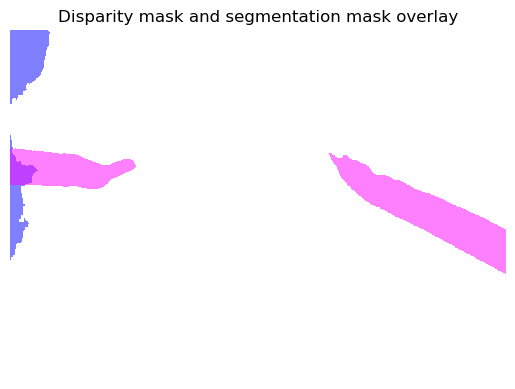

In [37]:

masked_data_disp = np.ma.masked_where(disp_mask == 0, disp_mask)
plt.imshow(masked_data_disp, cmap='winter', alpha=0.5)
masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
plt.title('Disparity mask and segmentation mask overlay')
plt.axis('off') 
plt.show()

In [38]:
def get_outlier_frames(df, threshold=100, num_samples=10):
    """
    Counts outliers and returns a list of frame names for random samples.
    """
    # 1. Filter for rows higher than threshold
    outliers = df[df['Hausdorff distance'] > threshold]
    
    # 2. Get the count
    total_outliers = len(outliers)
    print(f"Count of frames with Hausdorff > {threshold}: {total_outliers}")
    
    # 3. Sample and extract 'Frame' names
    # min() prevents errors if you have fewer than 10 outliers
    sample_count = min(num_samples, total_outliers)
    
    if sample_count > 0:
        sample_frames = outliers.sample(n=sample_count)['Frame'].tolist()
        return sample_frames
    else:
        return []

# Usage:
problematic_frames = get_outlier_frames(mask_df)
print(f"Sampled Frames: {problematic_frames}")

Count of frames with Hausdorff > 100: 1493
Sampled Frames: ['vid_000030_frame_000744', 'vid_000017_frame_000618', 'vid_000004_frame_000294', 'vid_000001_frame_000390', 'vid_000030_frame_000981', 'vid_000030_frame_000417', 'vid_000007_frame_000609', 'vid_000007_frame_000084', 'vid_000033_frame_000591', 'vid_000033_frame_000690']


In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

def visualize_outlier_overlays(frame_list, base_dir=''):
    """
    Constructs paths from frame names, runs metrics, and plots overlays in a grid with a global legend.
    """
    num_frames = len(frame_list)
    if num_frames == 0:
        print("No frames provided for visualization.")
        return


    cols = 5
    rows = (num_frames + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    

    if num_frames == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, frame_name in enumerate(frame_list):
      
        video_id = frame_name.split('_')[1]
        
  
        file_path = Path(base_dir) / video_id / 'compressed_data' / f"{frame_name}.npz"
        
        if not file_path.exists():
            print(f"Warning: File not found {file_path}")
            continue

        # 3. Load data
        data = np.load(file_path)
        disp_data = data['disparity']

     
        disp_thres, disp_mask, rect_mask_l, frame_id, hd, dice = disparity_vs_segmentation(
            mask_postprocess=True, 
            rect_mode='conventional', 
            h=disp_data.shape[0], 
            w=disp_data.shape[1], 
            disp_file=file_path, 
            disp=disp_data
        )

        
        ax = axes[i]
        
     
        masked_disp = np.ma.masked_where(disp_mask == 0, disp_mask)
        ax.imshow(masked_disp, cmap='winter', alpha=0.5)
        
       
        masked_seg = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
        ax.imshow(masked_seg, cmap='spring', alpha=0.5)
        
        ax.set_title(f"HD: {hd:.1f} | Dice: {dice:.2f}\n{frame_name}", fontsize=9)
        ax.axis('off')

    # 6. Create Legend Handles
    # Cyan roughly represents 'winter' and HotPink represents 'spring'
    disp_patch = mpatches.Patch(color='#8181f7', label='Disparity Mask ')
    seg_patch = mpatches.Patch(color='#d158f7', label='Segmentation Mask ')

    # Add a global legend to the bottom of the figure
    fig.legend(handles=[disp_patch, seg_patch], 
               loc='lower center', 
               ncol=2, 
               fontsize=12,
               bbox_to_anchor=(0.5, 0.02))

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.05, 1, 1]) 
    plt.show()

Count of frames with Hausdorff > 100: 1493


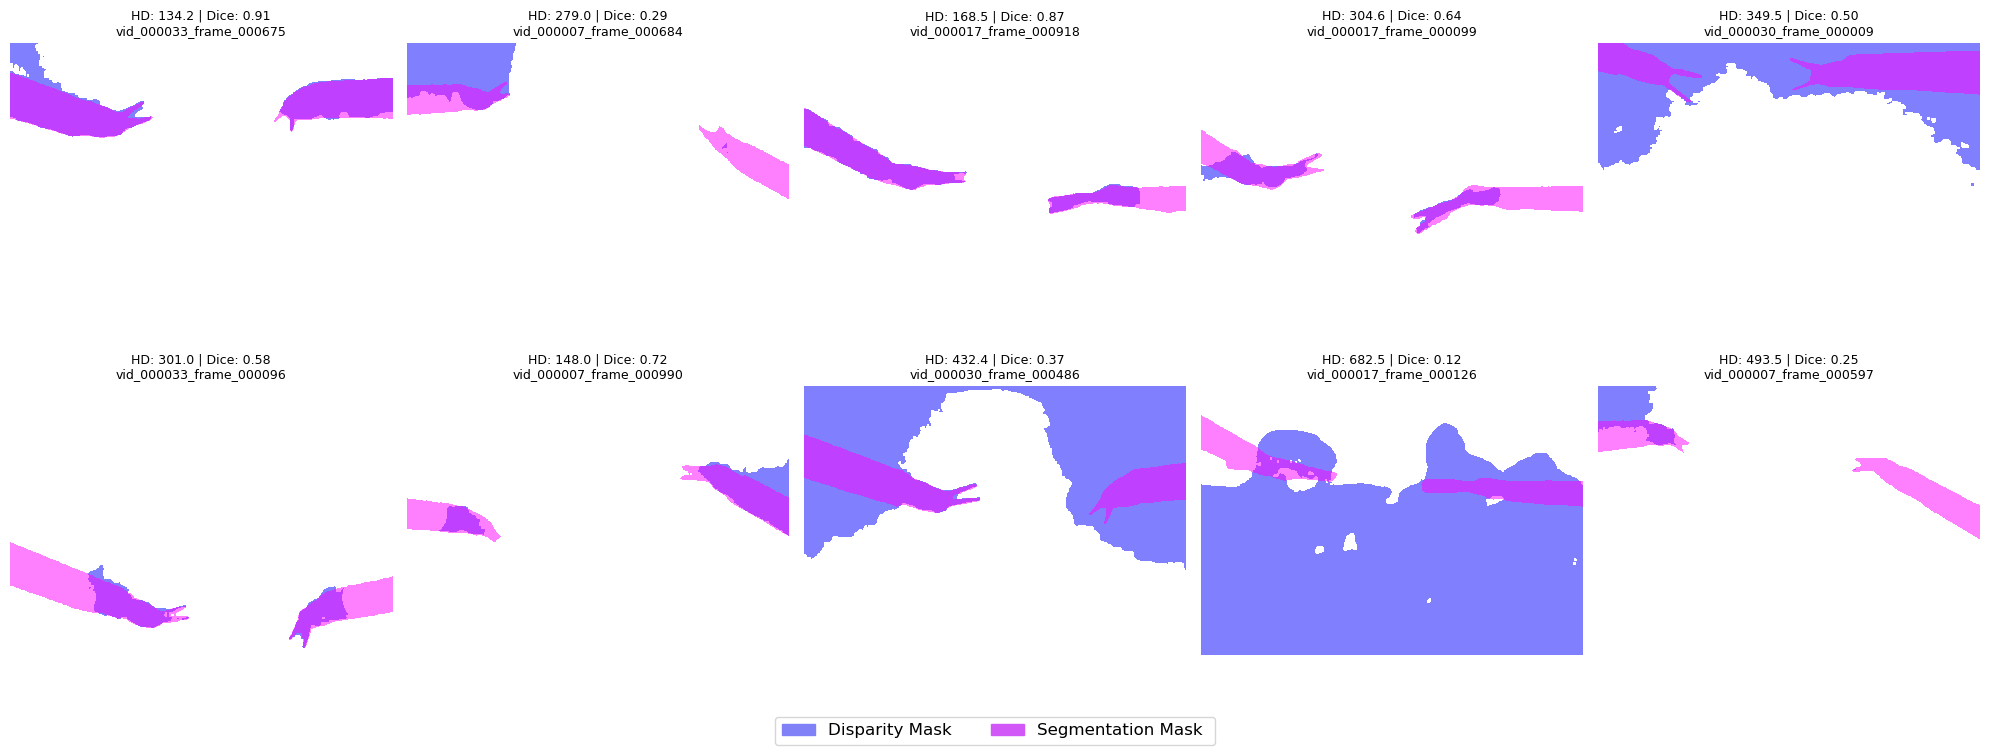

In [40]:

problematic_frames = get_outlier_frames(mask_df, threshold=100) 
visualize_outlier_overlays(problematic_frames,base_dir='results/Stereo_matching/Surgpose_test_disparity_maps/raftstereo')

###  SGBM results


+ #### Examples and plots

In [41]:

results_dir= "results/Stereo_matching/Surgpose_test_disparity_maps/sgbm"
selected_files= select_random_files(results_dir, num_examples, seed, file_path_structure="**/compressed_data/*.npz")
save_path= results_dir +  '/plots/'+ fig_name


In [42]:
sgbm_disparities=[]
for file in selected_files:
    data=np.load(file)
    sgbm_disparities.append(data['disparity'])

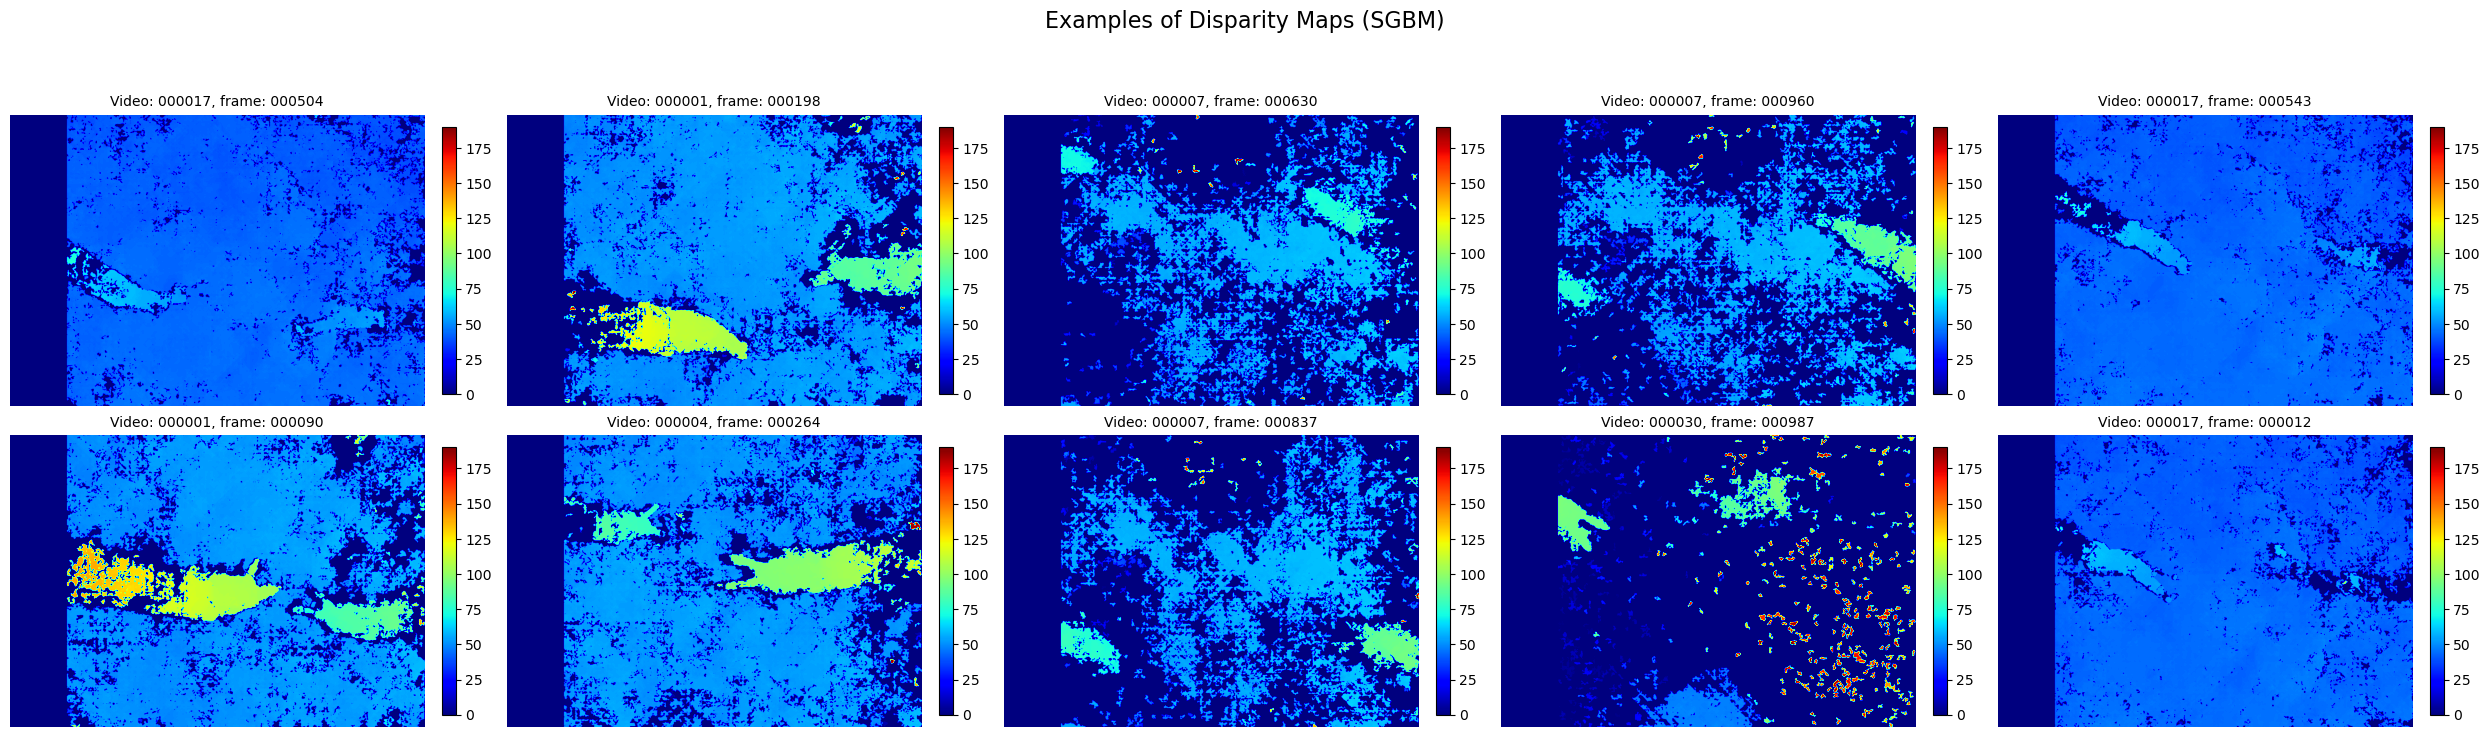

In [43]:
plot_selected_files(selected_files, disparities=sgbm_disparities, title= 'Examples of Disparity Maps (SGBM)', save_path=save_path, save= True, vid_id_position=1)

In [44]:
selected_example_path= selected_files[idx]

In [45]:
left_mask_path, right_mask_path, zip_calib_path, left_img_path, right_img_path, frame_id=get_file_paths_from_compressed_file_path(selected_example_path,vid_id_position=1)

In [46]:
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path);

In [47]:
# Load data
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [48]:
# rectify
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


In [49]:
# get left disparity and lrc_mask
data = np.load(selected_example_path)
disp_l =  data['disparity']
lrc_error = data['lrc_error']


In [52]:
# 3D reconstruction
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(disp_l, q, rect_l, rect_mask_l)

In [53]:
# Plot 3D reconstruction
visualizer = TriangulationVisualizer()
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id+ f', SGBM original')

+ #### Evaluation stats

In [54]:
import pandas as pd
lrc_stats='results/Stereo_matching/Surgpose_test_disparity_maps/sgbm/lrc_stats_20260423_133557.csv'
df= pd.read_csv(lrc_stats)

In [55]:
df.head(10)

,video_id,frame,lrc_mean,lrc_std,lrc_max,lrc_min,consistency_rate,ssim_score,lrc_median
0,4,vid_000004_left_frame_000000,15.1708,26.5267,190.9375,0.0,71.85,0.5638,0.1875
1,4,vid_000004_left_frame_000003,16.0637,27.0515,171.8750,0.0,70.44,0.5398,0.1719
2,4,vid_000004_left_frame_000006,15.5815,26.9299,186.3750,0.0,71.56,0.5446,0.1484
3,4,vid_000004_left_frame_000009,15.5785,26.9231,191.2500,0.0,71.47,0.5404,0.1562
4,4,vid_000004_left_frame_000012,16.1937,27.3084,185.1875,0.0,70.50,0.5245,0.1641
5,4,vid_000004_left_frame_000015,15.7112,27.1111,186.1250,0.0,71.48,0.5402,0.1523
6,4,vid_000004_left_frame_000018,16.0514,27.3069,192.0000,0.0,70.84,0.5390,0.1602
7,4,vid_000004_left_frame_000021,16.1758,27.4495,191.0000,0.0,70.66,0.5409,0.1680
8,4,vid_000004_left_frame_000024,16.3592,27.5710,189.0625,0.0,70.26,0.5199,0.1719
9,4,vid_000004_left_frame_000027,16.7489,27.7536,192.0000,0.0,69.70,0.5335,0.1680


In [56]:
df.mean(numeric_only=True).drop('video_id')

lrc_mean             14.096764
lrc_std              28.432057
lrc_max             177.183034
lrc_min               0.000000
consistency_rate     75.371831
ssim_score            0.498727
lrc_median            0.074847
dtype: float64

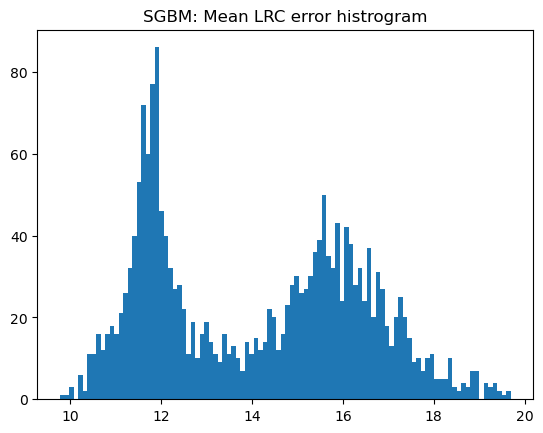

In [57]:
plt.hist(df['lrc_mean'], bins=100)
plt.title('SGBM: Mean LRC error histrogram')
plt.show()

#### Identifying a Problem with the segmentation masks

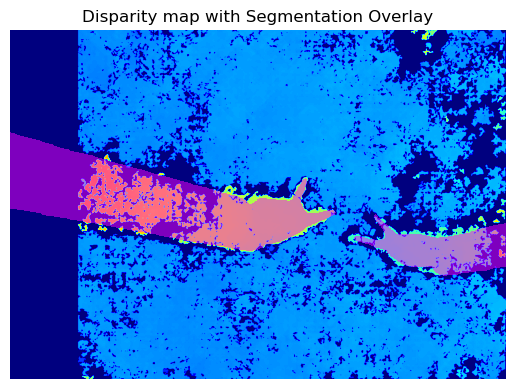

In [58]:

plt.imshow(disp_l, cmap='jet', vmin=0, vmax=190)
masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
plt.title('Disparity map with Segmentation Overlay')
plt.axis('off') 
plt.show()

In [59]:
#Erode segmentation mask
eroded_mask= erode_mask(rect_mask_l, iterations=3)

In [60]:
points_3d_cloud_eroded, colors, disparity = triangulator.project_disparity_to_3d(disp_l, q, rect_l, eroded_mask)

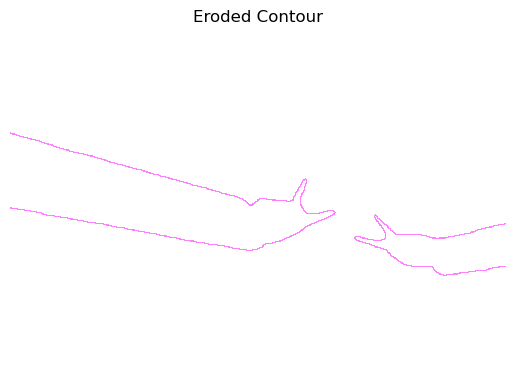

In [61]:

masked_data = np.ma.masked_where(rect_mask_l == 0, rect_mask_l)
plt.imshow(masked_data, cmap='spring', alpha=0.5)
masked_data_eroded = np.ma.masked_where(eroded_mask == 0, eroded_mask)
plt.imshow(masked_data_eroded, cmap='binary', alpha=1)
plt.title('Eroded Contour')
plt.axis('off') 
plt.show()

In [64]:
# Plot 3D reconstruction
visualizer = TriangulationVisualizer()

In [65]:

visualizer.plot_3d_plotly(points_3d=points_3d_cloud_eroded, colors=colors, frame_name=frame_id+', SGBM with eroded segmentation mask')